In [145]:
import pandas as pd

def load_bottom_metrics(path):
    """
    Load the aggregated bottom-level metrics CSV.
    Expected columns
    
      - bottom
      - bert_F1_mean, bert_F1_count
      - sbert_cosine_mean, sbert_cosine_count
      - rougeL_F1_mean, rougeL_F1_count
      - meteor_mean, meteor_count
    """
    return pd.read_csv(path)


def rank_bottom_categories(
    df_bottom,
    metric="bert_F1_mean",
    count_col="bert_F1_count",
    min_n=10,
    k=3,
):
    """
    From an aggregated bottom-level DataFrame, return top-k and bottom-k
    categories according to `metric`, after filtering by `min_n` in `count_col`.
    """
    # Filter by minimum number of instances
    df_filt = df_bottom[df_bottom[count_col] >= min_n].copy()

    if df_filt.empty:
        print(f"No categories with {count_col} >= {min_n}.")
        return None, None

    # Sort descending by metric
    df_sorted = df_filt.sort_values(metric, ascending=False)

    # Top-k (best)
    top_k = df_sorted.head(k)

    # Bottom-k (worst)
    bottom_k = df_sorted.tail(k).sort_values(metric, ascending=True)

    return top_k, bottom_k

import pandas as pd
import matplotlib.pyplot as plt

def plot_bottom_full(df_bottom, model_name, metric="bert_F1_mean", min_n=10):
    """
    Plot all bottom-level categories sorted by the chosen metric.
    df_bottom must contain: bottom, <metric>, <metric>_count.
    """

    # detect count column
    count_col_candidates = [c for c in df_bottom.columns if c.endswith("_count")]
    if not count_col_candidates:
        raise ValueError("No *_count column found.")
    count_col = count_col_candidates[0]

    # filter by minimum count
    df = df_bottom[df_bottom[count_col] >= min_n].copy()
    df = df.sort_values(metric, ascending=False)

    plt.figure(figsize=(10, max(4, len(df) * 0.35)))
    plt.barh(df["bottom"][::-1], df[metric][::-1], color="steelblue")
    plt.xlabel(metric)
    plt.ylabel("Bottom-Level Category")
    plt.title(f"{model_name}: Bottom-Level Ranking ({metric})")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return df


In [146]:
METRIC_COL = "sbert_cosine_mean"
# METRIC_COL = "bert_F1_mean"
# METRIC_COL = "rougeL_F1_mean"
# METRIC_COL = "meteor_mean"


GPT – top 3 bottom-level categories (by bert_F1_mean):
                     bottom  bert_F1_mean  bert_F1_count  sbert_cosine_mean  \
4                     Heavy      0.887632             23           0.681456   
1                  Crossing      0.906157             42           0.664100   
15  Moving forward:Normally      0.872726            127           0.632110   
10                    Light      0.876872             18           0.618473   
13    Moving forward:Slowly      0.873352             94           0.613974   

    sbert_cosine_count  rougeL_F1_mean  rougeL_F1_count  meteor_mean  \
4                   23        0.181981               23     0.119074   
1                   42        0.327241               42     0.239540   
15                 127        0.170803              127     0.105408   
10                  18        0.135254               18     0.085178   
13                  94        0.180258               94     0.100056   

    meteor_count  
4             23  

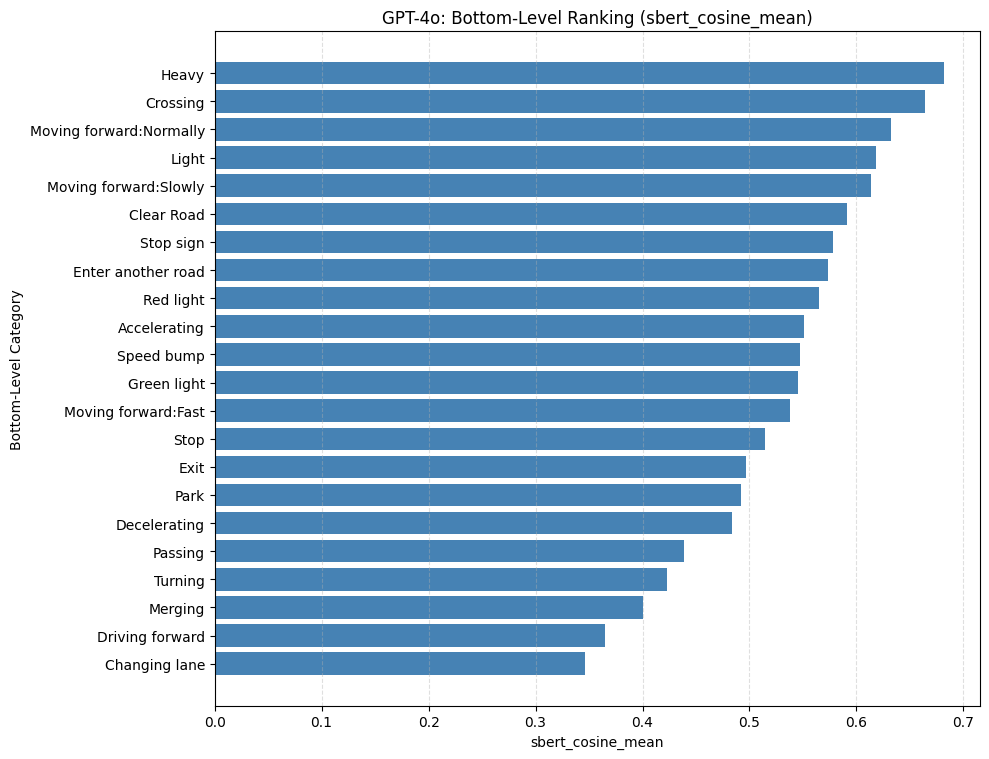

,bottom,bert_F1_mean,bert_F1_count,sbert_cosine_mean,sbert_cosine_count,rougeL_F1_mean,rougeL_F1_count,meteor_mean,meteor_count
4,Heavy,0.887632,23,0.681456,23,0.181981,23,0.119074,23
1,Crossing,0.906157,42,0.664100,42,0.327241,42,0.239540,42
15,Moving forward:Normally,0.872726,127,0.632110,127,0.170803,127,0.105408,127
10,Light,0.876872,18,0.618473,18,0.135254,18,0.085178,18
13,Moving forward:Slowly,0.873352,94,0.613974,94,0.180258,94,0.100056,94
8,Clear Road,0.880024,281,0.591158,281,0.182131,281,0.132034,281
2,Stop sign,0.898121,66,0.578518,66,0.351514,66,0.290435,66
14,Enter another road,0.873062,29,0.573793,29,0.153661,29,0.080662,29
3,Red light,0.889985,324,0.564936,324,0.265516,324,0.167658,324
16,Accelerating,0.871671,35,0.550934,35,0.208038,35,0.111939,35


In [147]:
# e.g. bottom metrics for GPT
gpt_bottom = load_bottom_metrics("eval_outputs_gpt4o/metrics_per_bottom.csv")

gpt_top3, gpt_worst3 = rank_bottom_categories(
    gpt_bottom,
    metric=METRIC_COL,
    count_col="bert_F1_count",
    min_n=10,
    k=5,
)

print("GPT – top 3 bottom-level categories (by bert_F1_mean):")
print(gpt_top3)

print("\nGPT – worst 3 bottom-level categories (by bert_F1_mean):")
print(gpt_worst3)

plot_bottom_full(gpt_bottom, "GPT-4o", metric=METRIC_COL, min_n=10)



RAG – top 3 bottom-level categories (by bert_F1_mean):
                                              bottom  bert_F1_mean  \
1         Traffic Conditions:Traffic Light:Red light      0.918708   
3  Interaction with Other Road Users:Traffic:Movi...      0.902142   
4  Interaction with Other Road Users:Traffic:Movi...      0.903803   

   bert_F1_count  sbert_cosine_mean  sbert_cosine_count  rougeL_F1_mean  \
1            322           0.688629                 322        0.478544   
3             96           0.643710                  96        0.344392   
4             69           0.643325                  69        0.335306   

   rougeL_F1_count  meteor_mean  meteor_count  
1              322     0.325566           322  
3               96     0.264765            96  
4               69     0.227734            69  

RAG – worst 3 bottom-level categories (by bert_F1_mean):
                                               bottom  bert_F1_mean  \
38  Ego car driving intention: Vehicle lon

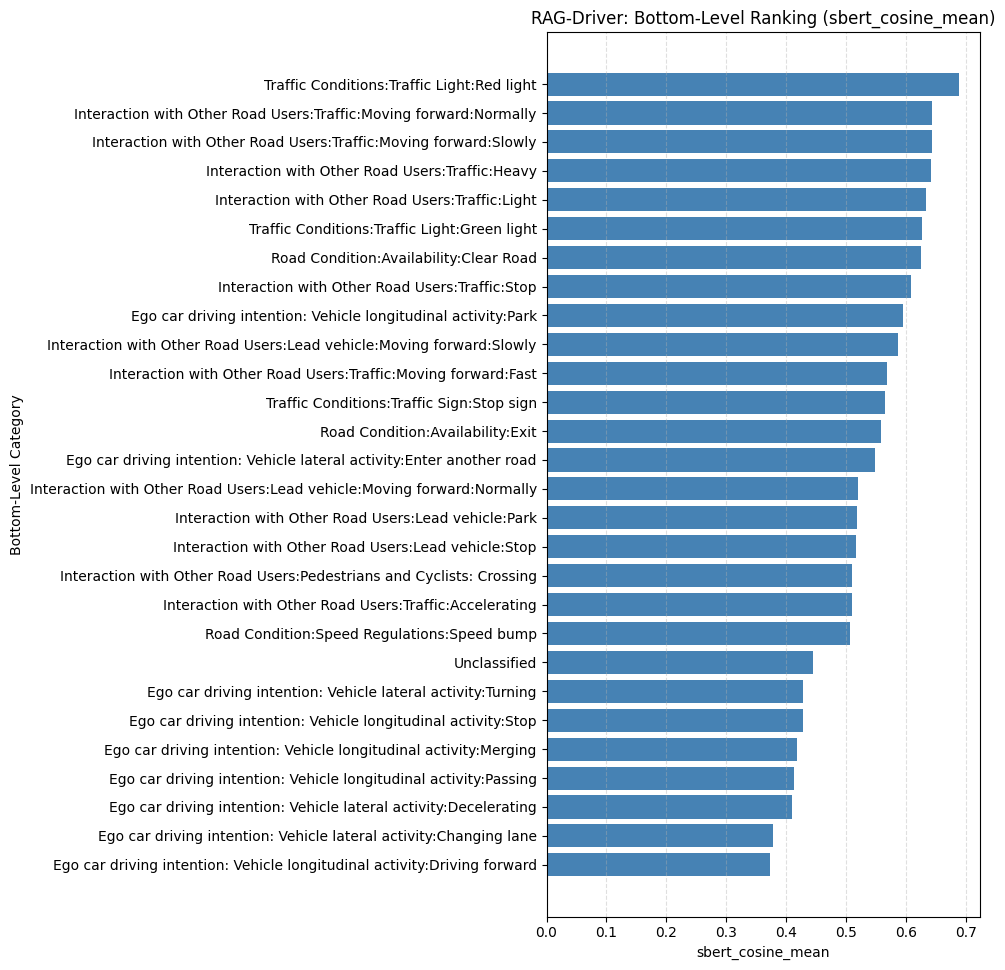

,bottom,bert_F1_mean,bert_F1_count,sbert_cosine_mean,sbert_cosine_count,rougeL_F1_mean,rougeL_F1_count,meteor_mean,meteor_count
1,Traffic Conditions:Traffic Light:Red light,0.918708,322,0.688629,322,0.478544,322,0.325566,322
3,Interaction with Other Road Users:Traffic:Movi...,0.902142,96,0.643710,96,0.344392,96,0.264765,96
4,Interaction with Other Road Users:Traffic:Movi...,0.903803,69,0.643325,69,0.335306,69,0.227734,69
5,Interaction with Other Road Users:Traffic:Heavy,0.896816,23,0.641942,23,0.264699,23,0.193774,23
7,Interaction with Other Road Users:Traffic:Light,0.900984,18,0.633735,18,0.335440,18,0.257549,18
8,Traffic Conditions:Traffic Light:Green light,0.909422,146,0.626634,146,0.430035,146,0.315184,146
9,Road Condition:Availability:Clear Road,0.905898,283,0.625411,283,0.368151,283,0.269659,283
10,Interaction with Other Road Users:Traffic:Stop,0.908050,91,0.607665,91,0.388615,91,0.237895,91
11,Ego car driving intention: Vehicle longitudina...,0.912653,63,0.595087,63,0.403170,63,0.282234,63
12,Interaction with Other Road Users:Lead vehicle...,0.898464,25,0.586514,25,0.274023,25,0.196418,25


In [148]:
rag_bottom = load_bottom_metrics("eval_outputs_rag_driver/metrics_per_bottom.csv")

rag_top3, rag_worst3 = rank_bottom_categories(
    rag_bottom,
    metric=METRIC_COL,
    count_col="bert_F1_count",
    min_n=10,
    k=3,
)

print("RAG – top 3 bottom-level categories (by bert_F1_mean):")
print(rag_top3)

print("\nRAG – worst 3 bottom-level categories (by bert_F1_mean):")
print(rag_worst3)

plot_bottom_full(rag_bottom, "RAG-Driver", metric=METRIC_COL, min_n=10)


In [149]:
metric_labels = {
    "sbert_cosine_mean": "SBERT cosine similarity (mean)",
    "sbert_cosine_median": "SBERT cosine similarity (median)",
    "bert_F1_mean": "BERTScore F1 (mean)",
    "bert_F1_median": "BERTScore F1 (median)",
    "rougeL_f1_mean": "ROUGE-L F1 (mean)",
    "bleu_mean": "BLEU (mean)",
}

def plot_top_bottom_k(df_bottom, model_name, metric="bert_F1_mean", min_n=10, k=3):

    # detect count column
    count_col = [c for c in df_bottom.columns if c.endswith("_count")][0]

    df = df_bottom[df_bottom[count_col] >= min_n].copy()
    df = df.sort_values(metric, ascending=False)

    top_k = df.head(k)
    bottom_k = df.tail(k).sort_values(metric, ascending=False)

    combined = pd.concat([top_k, bottom_k], axis=0)

    # ---- PROCESS LABELS ----
    def shorten_label(s):
        print(s)
        parts = str(s).split(":")
        if len(parts) <= 2:
            return s
        if len(parts) == 3:
            return parts[-1]
        return ":".join(parts[-2:])


    combined["short_label"] = combined["bottom"].apply(shorten_label)

    colors = ["green"] * k + ["red"] * k

    plt.figure(figsize=(8, 5))
    plt.barh(combined["short_label"], combined[metric], color=colors)

    # Font sizes = 18
    xlabel = metric_labels.get(metric, metric.replace("_", " ").title())
    plt.xlabel(xlabel, fontsize=16)
    plt.title(
        f"{model_name}: Top-{k} and Bottom-{k} Bottom-Level Categories",
        fontsize=18,
        loc="right",
        fontweight="bold",
        # x=0.0
    )

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=18)

    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return top_k, bottom_k


Heavy
Crossing
Moving forward:Normally
Turning
Driving forward
Changing lane


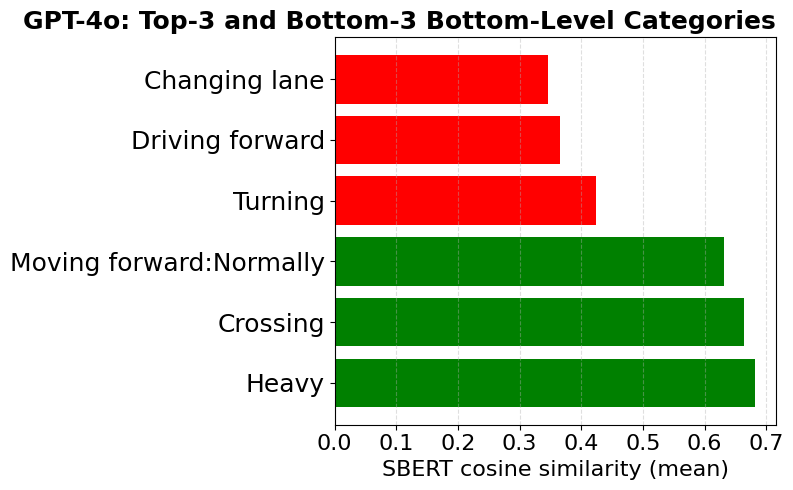

Traffic Conditions:Traffic Light:Red light
Interaction with Other Road Users:Traffic:Moving forward:Normally
Interaction with Other Road Users:Traffic:Moving forward:Slowly
Ego car driving intention: Vehicle longitudinal activity:Passing
Ego car driving intention: Vehicle lateral activity:Changing lane
Ego car driving intention: Vehicle longitudinal activity:Driving forward


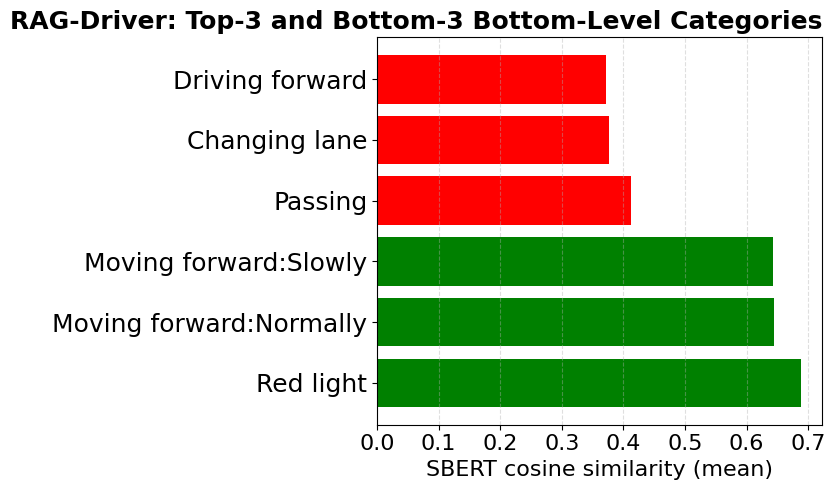

(                                              bottom  bert_F1_mean  \
 1         Traffic Conditions:Traffic Light:Red light      0.918708   
 3  Interaction with Other Road Users:Traffic:Movi...      0.902142   
 4  Interaction with Other Road Users:Traffic:Movi...      0.903803   
 
    bert_F1_count  sbert_cosine_mean  sbert_cosine_count  rougeL_F1_mean  \
 1            322           0.688629                 322        0.478544   
 3             96           0.643710                  96        0.344392   
 4             69           0.643325                  69        0.335306   
 
    rougeL_F1_count  meteor_mean  meteor_count  
 1              322     0.325566           322  
 3               96     0.264765            96  
 4               69     0.227734            69  ,
                                                bottom  bert_F1_mean  \
 35  Ego car driving intention: Vehicle longitudina...      0.870430   
 37  Ego car driving intention: Vehicle lateral act...      0.87235

In [150]:
plot_top_bottom_k(gpt_bottom, "GPT-4o", metric=METRIC_COL, min_n=20, k=3)
plot_top_bottom_k(rag_bottom, "RAG-Driver", metric=METRIC_COL, min_n=20, k=3)


In [151]:
def plot_gpt_vs_rag(df_gpt, df_rag, metric="bert_F1_mean", min_n=10):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd

    # detect counts
    gpt_count = [c for c in df_gpt.columns if c.endswith("_count")][0]
    rag_count = [c for c in df_rag.columns if c.endswith("_count")][0]

    # (optional but usually necessary) normalize keys to avoid whitespace/casing mismatches
    def norm_key(s):
        return str(s).strip()

    gpt = df_gpt.copy()
    rag = df_rag.copy()
    gpt["__key__"] = gpt["bottom"].map(norm_key)
    rag["__key__"] = rag["bottom"].map(norm_key)

    common = set(gpt["__key__"]) & set(rag["__key__"])
    print("Common categories (raw):", len(common))

    df_g = gpt[gpt["__key__"].isin(common) & (gpt[gpt_count] >= min_n)].copy()
    df_r = rag[rag["__key__"].isin(common) & (rag[rag_count] >= min_n)].copy()
    print("After min_n filter - GPT rows:", len(df_g), "RAG rows:", len(df_r))

    df = pd.merge(
        df_g[["__key__", "bottom", metric]].rename(columns={metric: metric + "_GPT"}),
        df_r[["__key__", metric]].rename(columns={metric: metric + "_RAG"}),
        on="__key__",
        how="inner"
    )
    print("After merge rows:", len(df))

    if len(df) == 0:
        print("Nothing to plot. Likely causes: no common 'bottom' labels after normalization, "
              "or min_n too high, or metric missing/NaN.")
        return df

    df = df.sort_values(metric + "_RAG", ascending=False)

    plt.figure(figsize=(10, max(4, len(df) * 0.35)))
    y = np.arange(len(df))
    width = 0.4

    plt.barh(y - width/2, df[metric + "_GPT"], height=width, label="GPT")
    plt.barh(y + width/2, df[metric + "_RAG"], height=width, label="RAG")

    plt.yticks(y, df["bottom"])
    plt.xlabel(metric.replace("_", " "))
    plt.title(f"GPT vs RAG on Bottom-Level Categories ({metric})")
    plt.legend()
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return df


In [152]:
import numpy as np
plot_gpt_vs_rag(gpt_bottom, rag_bottom, metric=METRIC_COL, min_n=10)


Common categories (raw): 0
After min_n filter - GPT rows: 0 RAG rows: 0
After merge rows: 0
Nothing to plot. Likely causes: no common 'bottom' labels after normalization, or min_n too high, or metric missing/NaN.


,__key__,bottom,sbert_cosine_mean_GPT,sbert_cosine_mean_RAG
